In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/nifty50_features.csv", index_col="Date", parse_dates=True)
df.head()

,Close,High,Low,Open,Volume,MA5,MA20,Daily_Return,Volatility,RSI14,Target
Date,,,,,,,,,,,
2015-01-30,8808.900391,8996.599609,8775.099609,8996.599609,267300,8884.329883,8529.457520,-0.016024,0.008323,79.062339,0
2015-02-02,8797.400391,8840.799805,8751.099609,8802.500000,210100,8876.690039,8549.555029,-0.001305,0.008466,77.102423,0
2015-02-03,8756.549805,8837.299805,8726.650391,8823.150391,208700,8845.900000,8568.462500,-0.004643,0.008815,75.612041,0
2015-02-04,8723.700195,8792.849609,8704.400391,8789.150391,195300,8807.780078,8598.280005,-0.003751,0.007329,74.691503,0
2015-02-05,8711.700195,8838.450195,8683.650391,8733.099609,173600,8759.650195,8628.760010,-0.001376,0.007234,65.564873,0


In [2]:
df[["Close", "MA5", "MA20", "Volatility", "RSI14"]].describe()

,Close,MA5,MA20,Volatility,RSI14
count,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000
mean,14566.951143,14554.228752,14505.636137,0.008618,55.203709
std,5720.725997,5712.863259,5684.932262,0.005503,17.286861
min,6970.600098,7023.129980,7170.400024,0.001982,2.022397
25%,9888.700195,9880.469922,9874.405029,0.005608,42.726955
50%,11937.650391,11941.300000,11869.414990,0.007405,54.862750
75%,18315.099609,18293.069922,18223.450098,0.009792,67.736090
max,26216.050781,26166.350000,26031.812695,0.066215,100.000000


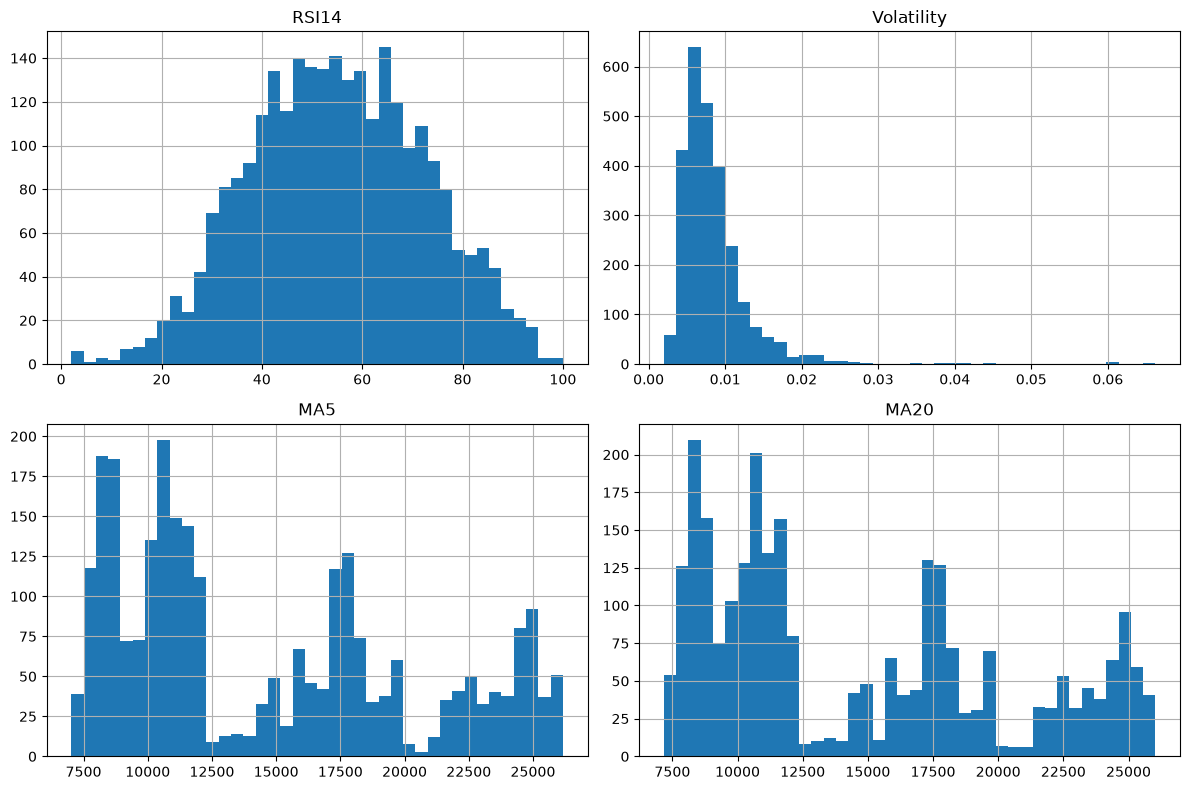

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df["RSI14"].hist(ax=axes[0,0], bins=40); axes[0,0].set_title("RSI14")
df["Volatility"].hist(ax=axes[0,1], bins=40); axes[0,1].set_title("Volatility")
df["MA5"].hist(ax=axes[1,0], bins=40); axes[1,0].set_title("MA5")
df["MA20"].hist(ax=axes[1,1], bins=40); axes[1,1].set_title("MA20")
plt.tight_layout()
plt.show()

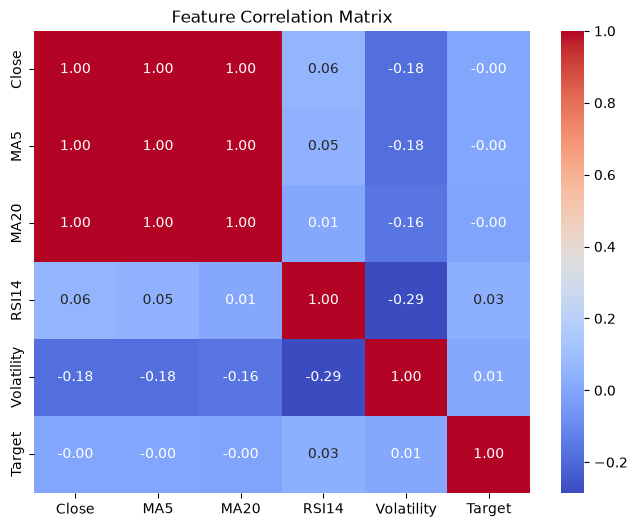

In [4]:
features = ["Close", "MA5", "MA20", "RSI14", "Volatility", "Target"]
corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

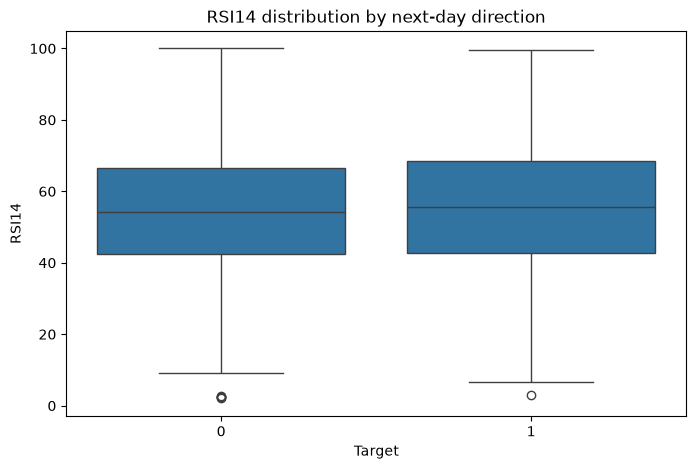

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Target", y="RSI14", data=df)
plt.title("RSI14 distribution by next-day direction")
plt.show()

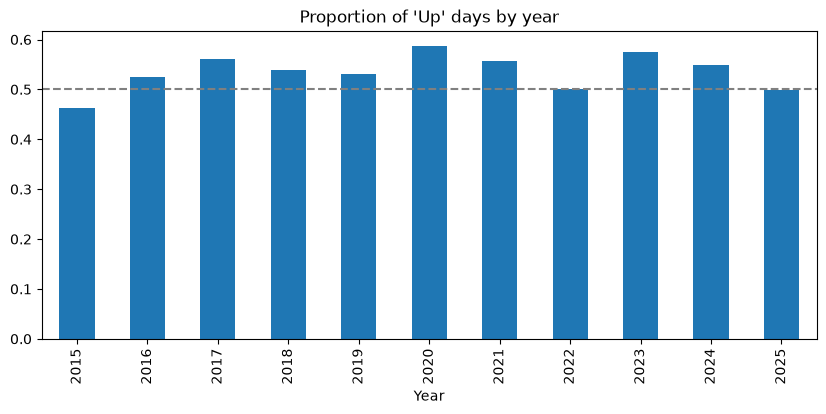

In [6]:
df["Year"] = df.index.year
yearly_balance = df.groupby("Year")["Target"].mean()
yearly_balance.plot(kind="bar", figsize=(10,4), title="Proportion of 'Up' days by year")
plt.axhline(0.5, color="gray", linestyle="--")
plt.show()

In [7]:
print(df[features].isna().sum())
print(np.isinf(df[features]).sum())

Close         0
MA5           0
MA20          0
RSI14         0
Volatility    0
Target        0
dtype: int64
Close         0
MA5           0
MA20          0
RSI14         0
Volatility    0
Target        0
dtype: int64
